# Parte 1 - Análisis de la base de datos

Dataset elegido: Heart Failure Prediction.

Fuente: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

El objetivo de esta parte es analizar la base antes de usarla para entrenar una red neuronal de clasificación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.shape

(918, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [9]:
df["HeartDisease"].value_counts(normalize=True) * 100

HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64

In [10]:
df_encoded = pd.get_dummies(df, drop_first=False)
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [11]:
correlaciones = df_encoded.corr(numeric_only=True)["HeartDisease"].sort_values(ascending=False)
correlaciones

HeartDisease         1.000000
ST_Slope_Flat        0.554134
ChestPainType_ASY    0.516716
ExerciseAngina_Y     0.494282
Oldpeak              0.403951
Sex_M                0.305445
Age                  0.282039
FastingBS            0.267291
ST_Slope_Down        0.122527
RestingBP            0.107589
RestingECG_ST        0.102527
RestingECG_LVH       0.010670
ChestPainType_TA    -0.054790
RestingECG_Normal   -0.091580
ChestPainType_NAP   -0.212964
Cholesterol         -0.232741
Sex_F               -0.305445
MaxHR               -0.400421
ChestPainType_ATA   -0.401924
ExerciseAngina_N    -0.494282
ST_Slope_Up         -0.622164
Name: HeartDisease, dtype: float64

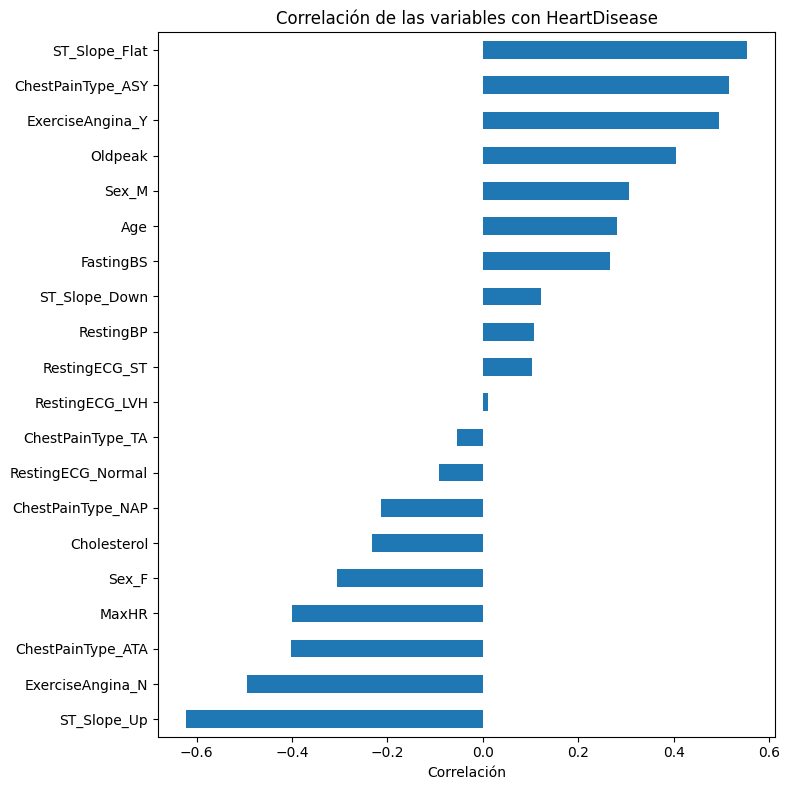

In [12]:
plt.figure(figsize=(8, 8))
correlaciones.drop("HeartDisease").sort_values().plot(kind="barh")
plt.title("Correlación de las variables con HeartDisease")
plt.xlabel("Correlación")
plt.tight_layout()
plt.show()

In [13]:
columnas_revisar = ["RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

for col in columnas_revisar:
    print(col, "valores iguales a 0:", (df[col] == 0).sum())

RestingBP valores iguales a 0: 1
Cholesterol valores iguales a 0: 172
MaxHR valores iguales a 0: 0
Oldpeak valores iguales a 0: 368


In [14]:
columnas_numericas = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

def detectar_atipicos_iqr(data, columna):
    q1 = data[columna].quantile(0.25)
    q3 = data[columna].quantile(0.75)
    iqr = q3 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    atipicos = data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]
    
    return limite_inferior, limite_superior, len(atipicos)

for col in columnas_numericas:
    li, ls, cantidad = detectar_atipicos_iqr(df, col)
    print(f"{col}: límite inferior = {li:.2f}, límite superior = {ls:.2f}, atípicos = {cantidad}")

Age: límite inferior = 27.50, límite superior = 79.50, atípicos = 0
RestingBP: límite inferior = 90.00, límite superior = 170.00, atípicos = 28
Cholesterol: límite inferior = 32.62, límite superior = 407.62, atípicos = 183
MaxHR: límite inferior = 66.00, límite superior = 210.00, atípicos = 2
Oldpeak: límite inferior = -2.25, límite superior = 3.75, atípicos = 16


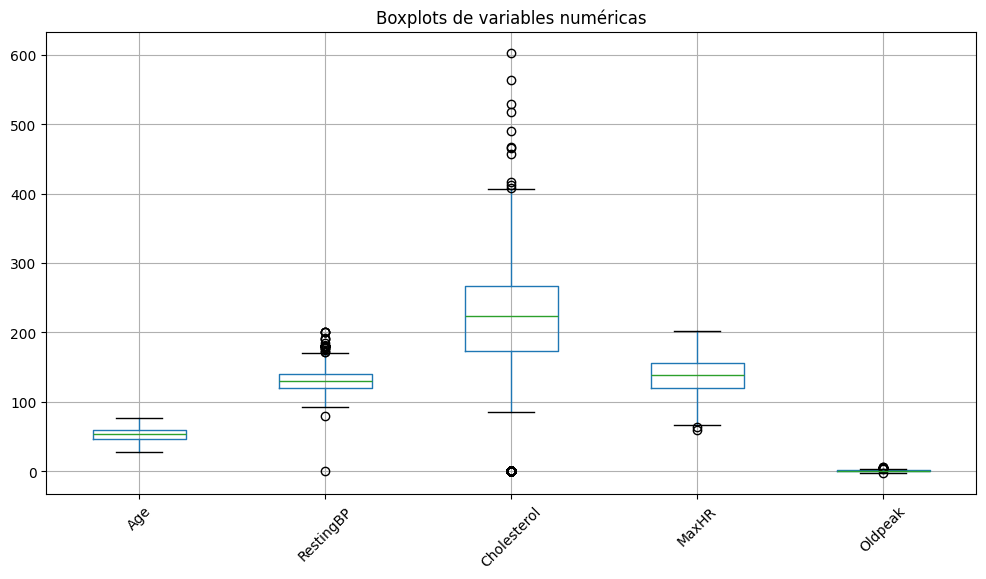

In [15]:
plt.figure(figsize=(12, 6))
df[columnas_numericas].boxplot()
plt.title("Boxplots de variables numéricas")
plt.xticks(rotation=45)
plt.show()

In [20]:
columnas_seleccionadas = [
    "ST_Slope",
    "ChestPainType",
    "ExerciseAngina",
    "Oldpeak",
    "MaxHR",
    "Age",
    "HeartDisease"
]

df_limpio = df[columnas_seleccionadas].copy()

df_limpio.head()

,ST_Slope,ChestPainType,ExerciseAngina,Oldpeak,MaxHR,Age,HeartDisease
0,Up,ATA,N,0.0,172,40,0
1,Flat,NAP,N,1.0,156,49,1
2,Up,ATA,N,0.0,98,37,0
3,Flat,ASY,Y,1.5,108,48,1
4,Up,NAP,N,0.0,122,54,0


In [21]:
df_limpio.shape

(918, 7)

In [22]:
df_limpio.isnull().sum()

ST_Slope          0
ChestPainType     0
ExerciseAngina    0
Oldpeak           0
MaxHR             0
Age               0
HeartDisease      0
dtype: int64

In [24]:
X = df_limpio.drop(columns=["HeartDisease"])
y = df_limpio["HeartDisease"]

X_encoded = pd.get_dummies(X, columns=["ST_Slope", "ChestPainType", "ExerciseAngina"], drop_first=False)

X_encoded.head()

,Oldpeak,MaxHR,Age,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,ExerciseAngina_N,ExerciseAngina_Y
0,0.0,172,40,False,False,True,False,True,False,False,True,False
1,1.0,156,49,False,True,False,False,False,True,False,True,False
2,0.0,98,37,False,False,True,False,True,False,False,True,False
3,1.5,108,48,False,True,False,True,False,False,False,False,True
4,0.0,122,54,False,False,True,False,False,True,False,True,False


In [25]:
columnas_a_normalizar = ["Oldpeak", "MaxHR", "Age"]

X_normalizado = X_encoded.copy()

X_normalizado[columnas_a_normalizar] = (
    X_normalizado[columnas_a_normalizar] - X_normalizado[columnas_a_normalizar].mean()
) / X_normalizado[columnas_a_normalizar].std()

X_normalizado.head()

,Oldpeak,MaxHR,Age,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,ExerciseAngina_N,ExerciseAngina_Y
0,-0.831979,1.382175,-1.432359,False,False,True,False,True,False,False,True,False
1,0.105606,0.753746,-0.478223,False,True,False,False,False,True,False,True,False
2,-0.831979,-1.524307,-1.750404,False,False,True,False,True,False,False,True,False
3,0.574398,-1.131539,-0.584238,False,True,False,True,False,False,False,False,True
4,-0.831979,-0.581664,0.051853,False,False,True,False,False,True,False,True,False


In [26]:
X_normalizado[columnas_a_normalizar].describe().round(2)

,Oldpeak,MaxHR,Age
count,918.00,918.00,918.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-3.27,-3.02,-2.70
25%,-0.83,-0.66,-0.69
50%,-0.27,0.05,0.05
75%,0.57,0.75,0.69
max,4.98,2.56,2.49
